#Proposta

Criar um modelo de recomendação de música, usando Pyspark

#Instalando e Criando uma Sessão no Pyspark

In [1]:
# Install Java
!apt-get update -qq > /dev/null
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# Download and extract Spark
!wget -q http://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz
!tar xf spark-3.5.0-bin-hadoop3.tgz

# Install PySpark
!pip install pyspark==3.5.0

# Set environment variables
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"

# Initialize SparkSession
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 15.5 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.5.0-py2.py3-none-any.whl size=317425346 sha256=5d9a3d6b3284624671189b219045a4d83606591a99a2ced4ddb4bb8da474184a
  Stored in directory: /root/.cache/pip/wheels/84/40/20/65eefe766118e0a8f8e385cc3ed6e9eb7241c7e51cfc04c51a
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.9
    Uninstalling py4j-0.10.9.9:
      Successfully uninstalled py4j-0.10.9.9
  Attempting uninstall: pyspark
    Found existing installation: pyspark 4.0.1
    Uninstalling pyspark-4.0.1:
      Successfully uninstalled pyspark-4.0.1
ERROR

In [2]:
spark

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
print("Teste")

Teste


#Dicionário de Dados


Acousticness/Acústica: variável numérica; medida de confiança de 0,0 a 1,0 se a faixa é acústica. O 1.0 representa alta confiança de que a faixa é acústica.

Danceability/Dançabilidade: variável numérica; a dançabilidade descreve o quão adequada uma faixa é para dançar com base em uma combinação de elementos musicais, incluindo tempo, estabilidade do ritmo, força da batida e regularidade geral. Um valor de 0,0 é o menos e 1,0 é o mais dançável.

Duration_ms: variável numérica; a duração da trilha em milissegundos.

Duration_min: variável numérica; a duração da faixa em minutos.

Energy/Energia: variável numérica; energia é uma medida de 0,0 a 1,0 e representa uma medida perceptiva de intensidade e atividade. Normalmente, as faixas energéticas parecem rápidas, altas e barulhentas. Por exemplo, o death metal tem alta energia, enquanto um prelúdio de Bach tem uma pontuação baixa na escala. As características perceptivas que contribuem para este atributo incluem faixa dinâmica, intensidade percebida, timbre, taxa de início e entropia geral.

Explicit/Explícito: variável categórica; se a faixa tem ou não letras explícitas (verdadeiro = sim (1); falso = não(0), não OU desconhecido).

Id: o ID do Spotify para a faixa.

Instrumentalness/Instrumentalidade: variável numérica; prevê se uma faixa não contém vocais. Os sons “Ooh” e “aah” são tratados como instrumentais neste contexto. Faixas de rap ou de palavras faladas são claramente “vocais”. Quanto mais próximo o valor de instrumentalidade estiver de 1,0, maior a probabilidade de a faixa não conter conteúdo vocal. Valores acima de 0,5 destinam-se a representar faixas instrumentais, mas a confiança é maior à medida que o valor se aproxima de 1,0.

Key/Chave: variável numérica; a chave geral estimada da faixa. Os inteiros são mapeados para pitchs usando a notação padrão de Pitch Class. Por exemplo, 0 = C, 1 = C#/Db, 2 = D, e assim por diante. Se nenhuma chave foi detectada, o valor é -1.

Liveness/Ao vivo: variável numérica; detecta a presença de um público na gravação. Valores mais altos de vivacidade representam uma probabilidade maior de que a faixa tenha sido executada ao vivo. Um valor acima de 0,8 fornece uma forte probabilidade de que a faixa esteja ativa.

Loudness/Volume em dB: variável numérica; volume geral de uma faixa em decibéis (dB). Os valores de volume são calculados em média em toda a faixa e são úteis para comparar o volume relativo das faixas. A sonoridade é a qualidade de um som em relação à sua amplitude (“altura”), por medir a relação entre os picos e depressões de uma onda sonora. Os valores típicos variam entre -60 e 0 db.

Mode/Modo: variável numérica; o modo indica a modalidade (maior ou menor) de uma faixa, o tipo de escala da qual seu conteúdo melódico é derivado. Maior é representado por 1 e menor é 0.

Popularity/Popularidade: variável numérica; a popularidade de uma faixa é um valor entre 0 e 100, sendo 100 o mais popular. A popularidade é calculada por algoritmo e é baseada, em grande parte, no número total de execuções que a faixa teve e quão recentes são essas execuções.

Speechiness/Fala: variável numérica; detecta a presença de palavras faladas em uma faixa. Quanto mais exclusivamente falada a gravação (por exemplo, talk show, audiolivro, poesia), mais próximo de 1,0 será o valor do atributo. Valores acima de 0,66 descrevem faixas que provavelmente são feitas inteiramente de palavras faladas. Valores entre 0,33 e 0,66 descrevem faixas que podem conter música e fala, seja em seções ou em camadas, incluindo casos como música estilo rap. Os valores abaixo de 0,33 provavelmente representam músicas e outras faixas que não são de fala.

Tempo: variável numérica; tempo estimado geral de uma faixa em batidas por minuto (BPM). Na terminologia musical, tempo é a velocidade ou ritmo de uma determinada peça e deriva diretamente da duração média da batida.

Valence/Valência: variável numérica; medida de 0,0 a 1,0 descrevendo a positividade musical transmitida por uma faixa. Faixas com alta valência soam mais positivas (por exemplo, feliz, alegre, eufórica), enquanto faixas com baixa valência soam mais negativas (como, triste, deprimida, irritada).

# Leitura dos dados

In [5]:
from pyspark import SparkFiles

In [6]:
dados = spark.read.csv("/content/drive/MyDrive/Curso_Spark/dados_musicas.csv", header =True, sep =';', inferSchema=True)

In [7]:
dados.limit(5).show()

+------------------+----+------------+------------+------------+-----------+------------------+--------+--------------------+----------------+---+--------+-------------------+----+-------------------+----------+-----------+-------+--------------------+
|           valence|year|acousticness|     artists|danceability|duration_ms|            energy|explicit|                  id|instrumentalness|key|liveness|           loudness|mode|               name|popularity|speechiness|  tempo|        artists_song|
+------------------+----+------------+------------+------------+-----------+------------------+--------+--------------------+----------------+---+--------+-------------------+----+-------------------+----------+-----------+-------+--------------------+
|             0.285|2000|     0.00239|    Coldplay|       0.429|     266773|0.6609999999999999|       0|3AJwUDP919kvQ9Qco...|         1.21E-4| 11|   0.234|             -7.227|   1|             Yellow|        84|     0.0281|173.372|   Coldpla

In [8]:
dados.limit(5).toPandas()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,speechiness,tempo,artists_song
0,0.285,2000,0.00239,Coldplay,0.429,266773,0.661,0,3AJwUDP919kvQ9QcozQPxg,0.000121,11,0.2340,-7.227,1,Yellow,84,0.0281,173.372,Coldplay - Yellow
1,0.613,2000,0.14300,OutKast,0.843,270507,0.806,1,0I3q5fE6wg7LIfHGngUTnV,0.000000,4,0.0771,-5.946,0,Ms. Jackson,80,0.2690,94.948,OutKast - Ms. Jackson
2,0.400,2000,0.00958,Linkin Park,0.556,216880,0.864,0,60a0Rd6pjrkxjPbaKzXjfq,0.000000,3,0.2090,-5.870,0,In the End,84,0.0584,105.143,Linkin Park - In the End
3,0.543,2000,0.00664,3 Doors Down,0.545,233933,0.865,0,6ZOBP3NvffbU4SZcrnt1k6,0.000011,11,0.1680,-5.708,0,Kryptonite,78,0.0286,99.009,3 Doors Down - Kryptonite
4,0.760,2000,0.03020,Eminem,0.949,284200,0.661,1,3yfqSUWxFvZELEM4PmlwIR,0.000000,5,0.0454,-4.244,0,The Real Slim Shady,80,0.0572,104.504,Eminem - The Real Slim Shady


In [9]:
dados.printSchema()

root
 |-- valence: double (nullable = true)
 |-- year: integer (nullable = true)
 |-- acousticness: double (nullable = true)
 |-- artists: string (nullable = true)
 |-- danceability: double (nullable = true)
 |-- duration_ms: integer (nullable = true)
 |-- energy: double (nullable = true)
 |-- explicit: integer (nullable = true)
 |-- id: string (nullable = true)
 |-- instrumentalness: double (nullable = true)
 |-- key: integer (nullable = true)
 |-- liveness: double (nullable = true)
 |-- loudness: double (nullable = true)
 |-- mode: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- popularity: integer (nullable = true)
 |-- speechiness: double (nullable = true)
 |-- tempo: double (nullable = true)
 |-- artists_song: string (nullable = true)



In [10]:
dados.count() # Quantidade de linhas

20311

In [11]:
len(dados.columns) # Quantidade de features

19

In [12]:
import pyspark.sql.functions as f

Verificando valores nulos

In [13]:
dados.select([f.count(f.when(f.isnull(c), 1)).alias(c) for c in dados.columns]).show()

+-------+----+------------+-------+------------+-----------+------+--------+---+----------------+---+--------+--------+----+----+----------+-----------+-----+------------+
|valence|year|acousticness|artists|danceability|duration_ms|energy|explicit| id|instrumentalness|key|liveness|loudness|mode|name|popularity|speechiness|tempo|artists_song|
+-------+----+------------+-------+------------+-----------+------+--------+---+----------------+---+--------+--------+----+----+----------+-----------+-----+------------+
|      0|   0|           0|      0|           0|          0|     0|       0|  0|               0|  0|       0|       0|   0|   0|         0|          0|    0|           0|
+-------+----+------------+-------+------------+-----------+------+--------+---+----------------+---+--------+--------+----+----+----------+-----------+-----+------------+



In [14]:
dados.select('year').distinct().show()

+----+
|year|
+----+
|2003|
|2007|
|2018|
|2015|
|2006|
|2013|
|2014|
|2019|
|2004|
|2020|
|2012|
|2009|
|2016|
|2001|
|2005|
|2000|
|2010|
|2011|
|2008|
|2017|
+----+
only showing top 20 rows



#Análise dos dados

Vamos usar outra base de dados para a análise com base nos anos.


Essa segunda base tem informações médias por ano.

Queremos identificar como o passar dos anos vem alterando as variáveis

In [15]:
dados_anos = spark.read.csv("/content/drive/MyDrive/Curso_Spark/dados_musicas_ano.csv", header =True, inferSchema=True)

In [16]:
dados_anos.limit(5).toPandas()

,mode,year,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,1921,0.886896,0.418597,260537.166667,0.231815,0.344878,0.205710,-17.048667,0.073662,101.531493,0.379327,0.653333,2
1,1,1922,0.938592,0.482042,165469.746479,0.237815,0.434195,0.240720,-19.275282,0.116655,100.884521,0.535549,0.140845,10
2,1,1923,0.957247,0.577341,177942.362162,0.262406,0.371733,0.227462,-14.129211,0.093949,114.010730,0.625492,5.389189,0
3,1,1924,0.940200,0.549894,191046.707627,0.344347,0.581701,0.235219,-14.231343,0.092089,120.689572,0.663725,0.661017,10
4,1,1925,0.962607,0.573863,184986.924460,0.278594,0.418297,0.237668,-14.146414,0.111918,115.521921,0.621929,2.604317,5


A primeira base de dados só tem músicas dos anos 2000
Vamos então filtrar a segunda base de dados para o mesmo período

In [17]:
dados_anos = dados_anos.filter(dados_anos.year > 1999)

In [18]:
dados_anos.limit(5).toPandas()

,mode,year,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,2000,0.289323,0.590918,242724.642638,0.625413,0.101168,0.197686,-8.247766,0.089205,118.999323,0.559475,46.684049,7
1,1,2001,0.286842,0.583318,240307.796010,0.626986,0.107214,0.187026,-8.305095,0.089182,117.765399,0.541479,48.750125,7
2,1,2002,0.282624,0.576160,239503.283000,0.641270,0.088048,0.193911,-7.686640,0.084308,119.239738,0.542397,48.655500,7
3,1,2003,0.256471,0.575763,244670.575230,0.660165,0.083049,0.196976,-7.485545,0.093926,120.914622,0.530504,48.626407,7
4,1,2004,0.280559,0.567680,237378.708037,0.648868,0.077934,0.202199,-7.601655,0.094239,121.290346,0.524489,49.273143,7


In [19]:
dados_anos.count()

21

In [20]:
len(dados_anos.columns)

14

##Gráficos

A biblioteca Plotly, semelhante às bibliotecas Matplotlib e Seaborn tem como seu propósito a criação de gráficos. Assim como a biblioteca Seaborn, que cria gráficos incríveis sem ser necessário muitas configurações, a Plotly vem com a proposta de trazer gráficos prontos para a apresentação e com o diferencial deles serem interativos, o que é muito útil em exploração e em apresentações.

### Criando um gráfico com plotly.express

Plotly Express permite criar a figura do gráfico toda de uma vez e é a melhor a opção para fazer gráficos mais comuns, porque vamos conseguir utilizar apenas uma linha de código e um gráfico muito bem formatado.

In [21]:
import plotly.express as px

In [22]:
fig = px.line(dados_anos.toPandas(), x = 'year', y = 'loudness', markers= True, title = 'Variação do loudness ao longo dos anos')
fig.show()

Graph Objects é uma representação mais complexa de uma figura, permitindo criar gráficos diferenciados com animações, por exemplo. Esse módulo é mais complexo de utilizar, já que precisamos de diversos métodos para cada elemento que vamos gerar no gráfico.

In [23]:
import plotly.graph_objects as go

In [24]:
fig = go.Figure()
temp = dados_anos.toPandas()
fig.add_trace(go.Scatter(x = temp.year, y = temp.acousticness, name = 'acousticness'))
fig.add_trace(go.Scatter(x = temp.year, y = temp.valence, name = 'valence'))
fig.add_trace(go.Scatter(x = temp.year, y = temp.danceability, name = 'danceability'))
fig.add_trace(go.Scatter(x = temp.year, y = temp.energy, name = 'energy'))
fig.add_trace(go.Scatter(x = temp.year, y = temp.instrumentalness, name = 'instrumentalness'))
fig.add_trace(go.Scatter(x = temp.year, y = temp.liveness, name = 'liveness'))
fig.add_trace(go.Scatter(x = temp.year, y = temp.speechiness, name = 'speechiness'))
fig.show()

#Matriz de correlação

In [25]:
fig = px.imshow(dados_anos.drop('mode').toPandas().corr(), text_auto = True)
fig.show()

#Clusterização por Genêro

In [26]:
dados_genero = spark.read.csv("/content/drive/MyDrive/Curso_Spark/dados_musicas_genero.csv", header =True, inferSchema=True)

In [27]:
dados_genero.limit(5).toPandas()

,mode,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,21st century classical,0.979333,0.162883,1.602977e+05,0.071317,0.606834,0.361600,-31.514333,0.040567,75.336500,0.103783,27.833333,6
1,1,432hz,0.494780,0.299333,1.048887e+06,0.450678,0.477762,0.131000,-16.854000,0.076817,120.285667,0.221750,52.500000,5
2,1,8-bit,0.762000,0.712000,1.151770e+05,0.818000,0.876000,0.126000,-9.180000,0.047000,133.444000,0.975000,48.000000,7
3,1,[],0.651417,0.529093,2.328809e+05,0.419146,0.205309,0.218696,-12.288965,0.107872,112.857352,0.513604,20.859882,7
4,1,a cappella,0.676557,0.538961,1.906285e+05,0.316434,0.003003,0.172254,-12.479387,0.082851,112.110362,0.448249,45.820071,7


In [28]:
dados_genero.count()

2973

In [29]:
dados_genero.select('genres').distinct().count()

2973

In [30]:
len(dados_genero.columns)

14

## StandardScaler
Vamos ajustar as escalas dos dados
Subtraindo a média e dividindo pelo desvio padrão, dessa forma a escala de todas as colunas ficam de 0 à 1.


In [31]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

In [32]:
dados_genero.columns

['mode',
 'genres',
 'acousticness',
 'danceability',
 'duration_ms',
 'energy',
 'instrumentalness',
 'liveness',
 'loudness',
 'speechiness',
 'tempo',
 'valence',
 'popularity',
 'key']

In [33]:
X = dados_genero.columns
X.remove('genres')

In [34]:
dados_generos_vector = VectorAssembler(inputCols = X, outputCol = 'features').transform(dados_genero).select(['features', 'genres'])

In [35]:
dados_generos_vector.limit(10).show(truncate = False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------+
|features                                                                                                                                                                                                                   |genres                |
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------+
|[1.0,0.9793333333333332,0.16288333333333335,160297.66666666663,0.07131666666666665,0.60683367,0.3616,-31.514333333333337,0.04056666666666667,75.3365,0.10378333333333334,27.83333333333333,6.0]                            |21st century classical|
|[1.0,0.49478,0.2993

In [36]:
scaler = StandardScaler(inputCol = 'features', outputCol = 'scaled_features')
scaler_model = scaler.fit(dados_generos_vector)
dados_generos_scaler = scaler_model.transform(dados_generos_vector)

In [37]:
dados_generos_scaler.show()

+--------------------+--------------------+--------------------+
|            features|              genres|     scaled_features|
+--------------------+--------------------+--------------------+
|[1.0,0.9793333333...|21st century clas...|[2.68174831000279...|
|[1.0,0.49478,0.29...|               432hz|[2.68174831000279...|
|[1.0,0.762,0.7120...|               8-bit|[2.68174831000279...|
|[1.0,0.6514170195...|                  []|[2.68174831000279...|
|[1.0,0.6765573049...|          a cappella|[2.68174831000279...|
|[1.0,0.45921,0.51...|            abstract|[2.68174831000279...|
|[1.0,0.3421466666...|      abstract beats|[2.68174831000279...|
|[1.0,0.2438540633...|    abstract hip hop|[2.68174831000279...|
|[0.0,0.3229999999...|           accordeon|[0.0,1.0101313736...|
|[1.0,0.446125,0.6...|           accordion|[2.68174831000279...|
|[0.0,0.0679505384...|          acid house|[0.0,0.2125045534...|
|[1.0,0.2569145079...|           acid rock|[2.68174831000279...|
|[1.0,0.00683,0.66...|   

#PCA - Principal Component Analysis

Utilizamos o PCA para reduzir as 14 features originais para apenas duas componentes principais, permitindo a criação de análises gráficas e um estudo mais aprofundado das informações.


PCA é um método clássico que podemos usar para reduzir dados de alta dimensionalidade para um espaço de baixa dimensão.

In [38]:
from pyspark.ml.feature import PCA

In [39]:
pca = PCA(k=1, inputCol='scaled_features', outputCol='pca_features')
pca_model = pca.fit(dados_generos_scaler)
dados_generos_pca = pca_model.transform(dados_generos_scaler)

In [40]:
dados_generos_pca.select('pca_features').show(truncate= False)

+----------------------+
|pca_features          |
+----------------------+
|[-2.5070953668885667] |
|[0.596967905663348]   |
|[4.158460276223559]   |
|[2.3873448785122156]  |
|[2.6501218371679065]  |
|[1.4965091203367615]  |
|[3.923520772157322]   |
|[4.611011109831113]   |
|[2.8376900630842288]  |
|[2.706690139892782]   |
|[4.698331383924286]   |
|[3.3759874966798664]  |
|[5.6089988770660195]  |
|[-0.29549463521176944]|
|[2.5725591062870405]  |
|[3.4008228020493436]  |
|[4.366720316263417]   |
|[2.725469816772399]   |
|[4.958112358381603]   |
|[3.6934951846422703]  |
+----------------------+
only showing top 20 rows



#Pipeline

In [41]:
from pyspark.ml import Pipeline

In [42]:
pca_pipeline = Pipeline(stages=[VectorAssembler(inputCols = X, outputCol = 'features'),
                                StandardScaler(inputCol = 'features', outputCol = 'scaled_features'),
                                PCA(k=2, inputCol='scaled_features', outputCol='pca_features')])


In [43]:
dados_genero_pca = pca_pipeline.fit(dados_genero).transform(dados_genero)

In [44]:
dados_genero_pca.show()

+----+--------------------+-------------------+-------------------+------------------+-------------------+--------------------+-------------------+-------------------+--------------------+------------------+-------------------+------------------+---+--------------------+--------------------+--------------------+
|mode|              genres|       acousticness|       danceability|       duration_ms|             energy|    instrumentalness|           liveness|           loudness|         speechiness|             tempo|            valence|        popularity|key|            features|     scaled_features|        pca_features|
+----+--------------------+-------------------+-------------------+------------------+-------------------+--------------------+-------------------+-------------------+--------------------+------------------+-------------------+------------------+---+--------------------+--------------------+--------------------+
|   1|21st century clas...| 0.9793333333333332|0.162883333

In [45]:
dados_genero_pca.select('pca_features').show(truncate= False)

+------------------------------------------+
|pca_features                              |
+------------------------------------------+
|[-2.5070953668885663,-0.43816913737698293]|
|[0.596967905663348,-4.981612052751353]    |
|[4.158460276223559,0.83665250810799]      |
|[2.3873448785122156,0.4877989015663361]   |
|[2.650121837167907,0.575681976882043]     |
|[1.4965091203367622,-1.8644183183717828]  |
|[3.9235207721573224,-0.28518350023528705] |
|[4.611011109831113,0.6783790472312338]    |
|[2.8376900630842288,0.57129937165805]     |
|[2.706690139892782,1.2593788079708255]    |
|[4.698331383924286,-1.2765569680619455]   |
|[3.375987496679866,-0.7560741064307498]   |
|[5.608998877066019,-1.042731164439324]    |
|[-0.2954946352117699,0.2763864586236268]  |
|[2.572559106287041,1.3169815431109746]    |
|[3.400822802049343,-0.5073029625781936]   |
|[4.366720316263417,0.33648270597710517]   |
|[2.7254698167723985,-0.5058604987046403]  |
|[4.958112358381603,-1.2627579957290722]   |
|[3.693495

# K-Means

In [46]:
from pyspark.ml.clustering import KMeans

In [47]:
SEED = 1224

In [48]:
kmeans = KMeans(featuresCol='pca_features', predictionCol='cluster_pca').setK(5).setSeed(SEED)

In [49]:
model_kmeans = kmeans.fit(dados_genero_pca)

In [50]:
predictions_kmeans = model_kmeans.transform(dados_genero_pca)

In [51]:
predictions_kmeans.select(['pca_features', 'cluster_pca']).show(truncate = False)

+------------------------------------------+-----------+
|pca_features                              |cluster_pca|
+------------------------------------------+-----------+
|[-2.5070953668885663,-0.43816913737698293]|2          |
|[0.596967905663348,-4.981612052751353]    |2          |
|[4.158460276223559,0.83665250810799]      |4          |
|[2.3873448785122156,0.4877989015663361]   |0          |
|[2.650121837167907,0.575681976882043]     |0          |
|[1.4965091203367622,-1.8644183183717828]  |2          |
|[3.9235207721573224,-0.28518350023528705] |4          |
|[4.611011109831113,0.6783790472312338]    |1          |
|[2.8376900630842288,0.57129937165805]     |4          |
|[2.706690139892782,1.2593788079708255]    |0          |
|[4.698331383924286,-1.2765569680619455]   |3          |
|[3.375987496679866,-0.7560741064307498]   |4          |
|[5.608998877066019,-1.042731164439324]    |1          |
|[-0.2954946352117699,0.2763864586236268]  |2          |
|[2.572559106287041,1.316981543

##Plotando o clustering

In [52]:
from pyspark.ml.functions import vector_to_array

In [53]:
pca_feartures_XY = predictions_kmeans.withColumn('X', vector_to_array('pca_features')[0])\
.withColumn('Y', vector_to_array('pca_features')[1])\
.select(['X', 'Y', 'cluster_pca', 'genres'])


In [54]:
pca_feartures_XY.show()

+-------------------+--------------------+-----------+--------------------+
|                  X|                   Y|cluster_pca|              genres|
+-------------------+--------------------+-----------+--------------------+
|-2.5070953668885663|-0.43816913737698293|          2|21st century clas...|
|  0.596967905663348|  -4.981612052751353|          2|               432hz|
|  4.158460276223559|    0.83665250810799|          4|               8-bit|
| 2.3873448785122156|  0.4877989015663361|          0|                  []|
|  2.650121837167907|   0.575681976882043|          0|          a cappella|
| 1.4965091203367622| -1.8644183183717828|          2|            abstract|
| 3.9235207721573224|-0.28518350023528705|          4|      abstract beats|
|  4.611011109831113|  0.6783790472312338|          1|    abstract hip hop|
| 2.8376900630842288|    0.57129937165805|          4|           accordeon|
|  2.706690139892782|  1.2593788079708255|          0|           accordion|
|  4.6983313

In [55]:
fig = px.scatter(pca_feartures_XY.toPandas(), x = 'X', y = 'Y', color = 'cluster_pca', hover_data = ['X', 'Y', 'genres'])
fig.show()

#Clusterização por Música

In [56]:
# Na definição da função vamos incluir os parâmetros que gostariamos de variar, como quantidade componentes, número de clusters e colunas utilizadas
def cria_pipeline(k_PCA=2, SEED=1224, k_kmeans=5, columns=X, data=dados_genero):


  # Definição do Pipeline
  # Primeiro a vetorização das colunas selecionadas
  # Segundo a padronização dos dados com o StandardScaler
  # Terceiro o PCA com o número k_PCA de componentes
  # Quarto o KMeans com o número k_kmeans de clusters
  pca_pipeline = Pipeline(stages=[VectorAssembler(inputCols = columns, outputCol = 'features'),\
                                StandardScaler(inputCol='features', outputCol='scaled_features'),\
                                PCA(k=k_PCA, inputCol="scaled_features", outputCol='pca_features'),\
                                KMeans(featuresCol='pca_features', predictionCol='cluster_pca', seed=SEED, k=k_kmeans)])

  # ajuste da pipeline com os dados
  model = pca_pipeline.fit(data)

  # transformação dos dados utilizando o modelo da pipeline
  predictions_kmeans = model.transform(data)

  # criando duas novas colunas a partir das primeiras duas componentes do PCA
  pca_features_xs = predictions_kmeans.withColumn("x", vector_to_array("pca_features")[0])\
                   .withColumn("y", vector_to_array("pca_features")[1])\
                   .select(['x', 'y', 'cluster_pca', 'genres'])

  # plotando as duas componentes e o cluster
  fig = px.scatter(
   pca_features_xs.toPandas(), x='x', y='y', color='cluster_pca', hover_data=['x', 'y', 'genres'])
  fig.show()

  # retornando pipeline ajustado
  return model

#Redução de dimensionalidade

In [57]:
X = dados.columns
X.remove('artists')
X.remove('id')
X.remove('name')
X.remove('artists_song')
X

['valence',
 'year',
 'acousticness',
 'danceability',
 'duration_ms',
 'energy',
 'explicit',
 'instrumentalness',
 'key',
 'liveness',
 'loudness',
 'mode',
 'popularity',
 'speechiness',
 'tempo']

In [60]:
dados_encoded_vector = VectorAssembler(inputCols = X, outputCol = 'features').transform(dados)

In [62]:
dados_encoded_vector.select('features').show(truncate= False, n=5)

+-------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                 |
+-------------------------------------------------------------------------------------------------------------------------+
|[0.285,2000.0,0.00239,0.429,266773.0,0.6609999999999999,0.0,1.21E-4,11.0,0.234,-7.227,1.0,84.0,0.0281,173.372]           |
|[0.613,2000.0,0.143,0.843,270507.0,0.8059999999999999,1.0,0.0,4.0,0.0771,-5.9460000000000015,0.0,80.0,0.269,94.948]      |
|[0.4,2000.0,0.00958,0.556,216880.0,0.8640000000000001,0.0,0.0,3.0,0.209,-5.87,0.0,84.0,0.0584,105.143]                   |
|[0.5429999999999999,2000.0,0.00664,0.545,233933.0,0.865,0.0,1.1E-5,11.0,0.168,-5.7079999999999975,0.0,78.0,0.0286,99.009]|
|[0.76,2000.0,0.0302,0.949,284200.0,0.6609999999999999,1.0,0.0,5.0,0.0454,-4.244,0.0,80.0,0.0572,104.504]                 |
+-------

In [63]:
scaler = StandardScaler(inputCol = 'features', outputCol = 'scaled_features')
model_scaler = scaler.fit(dados_encoded_vector)
dad0s_musica_scaler = model_scaler.transform(dados_encoded_vector)

In [64]:
dad0s_musica_scaler.select('features').show(truncate= False, n=5)

+-------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                 |
+-------------------------------------------------------------------------------------------------------------------------+
|[0.285,2000.0,0.00239,0.429,266773.0,0.6609999999999999,0.0,1.21E-4,11.0,0.234,-7.227,1.0,84.0,0.0281,173.372]           |
|[0.613,2000.0,0.143,0.843,270507.0,0.8059999999999999,1.0,0.0,4.0,0.0771,-5.9460000000000015,0.0,80.0,0.269,94.948]      |
|[0.4,2000.0,0.00958,0.556,216880.0,0.8640000000000001,0.0,0.0,3.0,0.209,-5.87,0.0,84.0,0.0584,105.143]                   |
|[0.5429999999999999,2000.0,0.00664,0.545,233933.0,0.865,0.0,1.1E-5,11.0,0.168,-5.7079999999999975,0.0,78.0,0.0286,99.009]|
|[0.76,2000.0,0.0302,0.949,284200.0,0.6609999999999999,1.0,0.0,5.0,0.0454,-4.244,0.0,80.0,0.0572,104.504]                 |
+-------

In [65]:
k = len(X)
k

15

In [66]:
pca = PCA(k=k, inputCol='scaled_features', outputCol='pca_features')
model_pca = pca.fit(dad0s_musica_scaler)
dados_musica_pca = model_pca.transform(dad0s_musica_scaler)

Usando .explainedVariance para verificar o quanto cada componente está explicando o modelo

Esses valores significam o percentual que cada componente explica da variação dos dados.

O método explainedVariance nos fornece uma lista com os percentuais de explicação de cada componente e a soma dos elementos dessa lista é o quanto está sendo explicado da variação do conjunto de dados.

In [68]:
model_pca.explainedVariance

DenseVector([0.213, 0.133, 0.0939, 0.0869, 0.0733, 0.0665, 0.0616, 0.0563, 0.0505, 0.0462, 0.0339, 0.0284, 0.0264, 0.0202, 0.0099])

In [69]:
sum(model_pca.explainedVariance) * 100

np.float64(100.00000000000003)

Está explicando 100 do modelo

Porém precisamos retirar variáveis

In [72]:
lista_valores = [sum(model_pca.explainedVariance[0:i+1]) for i in range(k)]
lista_valores

[np.float64(0.21297354127107349),
 np.float64(0.3459774162295507),
 np.float64(0.43989805678254446),
 np.float64(0.5267820578269103),
 np.float64(0.6001038103117929),
 np.float64(0.666571951365239),
 np.float64(0.7282174213581728),
 np.float64(0.7845103843321023),
 np.float64(0.8350002357002614),
 np.float64(0.8812446547406769),
 np.float64(0.9151737562703048),
 np.float64(0.9435370133056039),
 np.float64(0.9699018569070161),
 np.float64(0.9900947792885582),
 np.float64(1.0000000000000002)]

In [73]:
import numpy as np

Aqui identificamos que 6 componentes são o suficiente para explicar o modelo

In [75]:
k = sum(np.array(lista_valores) <= 0.7)
k

np.int64(6)

In [76]:
pca = PCA(k=k, inputCol='scaled_features', outputCol='pca_features')
model_pca = pca.fit(dad0s_musica_scaler)
dados_musicas_pca_final = model_pca.transform(dad0s_musica_scaler)

In [79]:
dados_musicas_pca_final.select('pca_features').show(truncate = False, n=5)

+----------------------------------------------------------------------------------------------------------------------+
|pca_features                                                                                                          |
+----------------------------------------------------------------------------------------------------------------------+
|[-34.71004464775702,-165.3684878490617,-11.163498729833675,-139.1137428085442,14.152192300931317,-6.254422223810444]  |
|[-36.49885762774904,-167.85185045616547,-10.729023248907904,-135.90435265671286,13.38840189058717,-3.972980727830917] |
|[-35.46030091694054,-165.99633344577876,-11.361290348241944,-138.24276881246985,13.866654919305718,-4.342675920458773]|
|[-35.56301325520582,-165.59515096480598,-11.46022600703173,-137.52095740570027,15.568542803922659,-4.542073725584329] |
|[-36.54556974907565,-167.37512505802474,-11.881276527236897,-136.27798590243967,14.056847990344485,-3.583390145779214]|
+-------------------------------

In [78]:
model_pca.explainedVariance

DenseVector([0.213, 0.133, 0.0939, 0.0869, 0.0733, 0.0665])

In [80]:
sum(model_pca.explainedVariance) * 100

np.float64(66.6571951365239)

# Criação dos clusters

In [81]:
pca_pipeline = Pipeline(stages=[VectorAssembler(inputCols=X, outputCol='features'),
                                                StandardScaler(inputCol='features', outputCol='features_scaled'),
                                                PCA(k=6, inputCol='features_scaled', outputCol='pca_features'),
                                                ])

In [82]:
model_pca_pipeline = pca_pipeline.fit(dados)

In [83]:
projection = model_pca_pipeline.transform(dados)

In [85]:
projection.select('pca_features').show(truncate = False)

+----------------------------------------------------------------------------------------------------------------------+
|pca_features                                                                                                          |
+----------------------------------------------------------------------------------------------------------------------+
|[-34.71004464775702,-165.3684878490617,-11.163498729833675,-139.1137428085442,14.152192300931317,-6.254422223810444]  |
|[-36.49885762774904,-167.85185045616547,-10.729023248907904,-135.90435265671286,13.38840189058717,-3.972980727830917] |
|[-35.46030091694054,-165.99633344577876,-11.361290348241944,-138.24276881246985,13.866654919305718,-4.342675920458773]|
|[-35.56301325520582,-165.59515096480598,-11.46022600703173,-137.52095740570027,15.568542803922659,-4.542073725584329] |
|[-36.54556974907565,-167.37512505802474,-11.881276527236897,-136.27798590243967,14.056847990344485,-3.583390145779214]|
|[-36.7132222902623,-166.4820848

In [86]:
kmeans = KMeans(k = 50, featuresCol='pca_features', predictionCol='cluster_pca', seed = SEED)

In [87]:
modelo_kmeans = kmeans.fit(projection)

In [88]:
projection_kmeans = modelo_kmeans.transform(projection)

In [89]:
projection_kmeans.select(['pca_features', 'cluster_pca']).show(truncate = False)

+----------------------------------------------------------------------------------------------------------------------+-----------+
|pca_features                                                                                                          |cluster_pca|
+----------------------------------------------------------------------------------------------------------------------+-----------+
|[-34.71004464775702,-165.3684878490617,-11.163498729833675,-139.1137428085442,14.152192300931317,-6.254422223810444]  |8          |
|[-36.49885762774904,-167.85185045616547,-10.729023248907904,-135.90435265671286,13.38840189058717,-3.972980727830917] |4          |
|[-35.46030091694054,-165.99633344577876,-11.361290348241944,-138.24276881246985,13.866654919305718,-4.342675920458773]|35         |
|[-35.56301325520582,-165.59515096480598,-11.46022600703173,-137.52095740570027,15.568542803922659,-4.542073725584329] |16         |
|[-36.54556974907565,-167.37512505802474,-11.881276527236897,-136.277

In [90]:
projection_kmeans = projection_kmeans.withColumn('x', vector_to_array('pca_features')[0])\
                    .withColumn('y', vector_to_array('pca_features')[1])

In [91]:
projection_kmeans.select(['x', 'y', 'cluster_pca', 'artists_song']).show(truncate = False)

+-------------------+-------------------+-----------+--------------------------------------------------------+
|x                  |y                  |cluster_pca|artists_song                                            |
+-------------------+-------------------+-----------+--------------------------------------------------------+
|-34.71004464775702 |-165.3684878490617 |8          |Coldplay - Yellow                                       |
|-36.49885762774904 |-167.85185045616547|4          |OutKast - Ms. Jackson                                   |
|-35.46030091694054 |-165.99633344577876|35         |Linkin Park - In the End                                |
|-35.56301325520582 |-165.59515096480598|16         |3 Doors Down - Kryptonite                               |
|-36.54556974907565 |-167.37512505802474|34         |Eminem - The Real Slim Shady                            |
|-36.7132222902623  |-166.482084830997  |34         |Disturbed - Down with the Sickness                      |
|

O objetivo do Pipeline é tornar o processo de transformação dos dados, que precisa ser executado na ordem correta, mais automático e de mais fácil entendimento. Mas antes, precisamos compreender dois conceitos:

Estimador: é qualquer objeto que tem a capacidade de prever alguns parâmetros com base em um conjunto de dados. O estimador realiza essa previsão se ajustando aos dados por meio do método .fit(). Logo, todo estimador deve possuir esse método.

Transformador: são estimadores que realizam transformação em um conjunto de dados. Nos transformadores, o método .fit() aprende os parâmetros como média e desvio padrão, que serão usados na normalização pelo método .transform(), fazendo a transformação nos dados.

##Analisando o cluster

In [92]:
fig = px.scatter(projection_kmeans.toPandas(), x = 'x', y = 'y', color = 'cluster_pca', hover_data =['artists_song'])
fig.show()

A visualização do cluster não conseguiu demonstrar se estamos conseguindo agrupar bem nossas músicas. Para tentar melhorar essa visualização, podemos variar a quantidade.

In [93]:
def exibir_clusters(k):
  kmeans = KMeans(k=k, featuresCol='pca_features', predictionCol='cluster_pca', seed=SEED)
  modelo_kmeans = kmeans.fit(projection)
  projetion_kmeans = modelo_kmeans.transform(projection)

  projetion_kmeans = projetion_kmeans.withColumn('x', vector_to_array('pca_features')[0])\
                                    .withColumn('y', vector_to_array('pca_features')[1])
  fig = px.scatter(projetion_kmeans.toPandas(), x='x', y='y', color='cluster_pca', hover_data=['artists_song'])
  fig.show()

In [94]:
exibir_clusters(20)

In [96]:
exibir_clusters(50)

#Distâncias das músicas

In [95]:
nome_musica = 'Taylor Swift - Blank Space'

Pegando o cluster em qual está a música da Taylor Swift - Blank Space

In [98]:
cluster = projection_kmeans.filter(projection_kmeans.artists_song == nome_musica).select('cluster_pca').collect()[0][0]
cluster

3

Agora vamos ver as outras músicas nesse cluster

In [100]:
musicas_recomendadas = projection_kmeans.filter(projection_kmeans.cluster_pca == cluster)\
.select('artists_song', 'id', 'pca_features')

In [101]:
musicas_recomendadas.show()

+--------------------+--------------------+--------------------+
|        artists_song|                  id|        pca_features|
+--------------------+--------------------+--------------------+
|Usher - Yeah! (fe...|5rb9QrpfcKFHM1EUb...|[-36.050436933493...|
|Kelly Clarkson - ...|3xrn9i8zhNZsTtcoW...|[-35.191226411336...|
| Keyshia Cole - Love|0W4NhJhcqKCqEP2GI...|[-34.751332435196...|
|Mariah Carey - We...|3LmvfNUQtglbTryds...|[-35.144610288312...|
|Korn - Coming Undone|6p2liQLGoDaLXgND6...|[-35.272207170621...|
|Chris Brown - Yo ...|7DFnq8FYhHMCylykf...|[-35.112344117719...|
|  Aventura - Un Beso|1SaEt8dwTuLDzenUu...|[-34.134357732463...|
|Chris Brown - Say...|5F7IJrXD6Fa3EmqoY...|[-34.728839526520...|
|Red Hot Chili Pep...|10Nmj3JCNoMeBQ87u...|[-36.101793760083...|
|Craig Morgan - In...|0Ta3jOf8m9yCSWMVw...|[-35.227552248025...|
|Arctic Monkeys - ...|3geFzA6VBSNZUTmV3...|[-34.696049351615...|
|Arctic Monkeys - 505|58ge6dfP91o9oXMzq...|[-35.057671072817...|
|T-Pain - Buy U a ...|2aI

Pegando as coordenadas da música de referência

In [104]:
componentes_musica = musicas_recomendadas.filter(musicas_recomendadas.artists_song == nome_musica)\
                          .select('pca_features').collect()[0][0]

In [105]:
componentes_musica

DenseVector([-35.461, -166.9658, -12.7925, -137.9457, 13.1234, -4.1374])

#Recomendação da música

In [109]:
from scipy.spatial.distance import euclidean
from pyspark.sql.types import FloatType

In [111]:
def calcular_distancia(value):
  return euclidean(componentes_musica, value)

udf_calcular_distancia = f.udf(calcular_distancia, FloatType())


Este código define uma função Python chamada `calcular_distancia` que calcula a distância euclidiana entre dois pontos. Ela recebe um valor como entrada e calcula sua distância euclidiana a partir de `components_musica` (que foi previamente definido como as características PCA de uma música de referência, 'Taylor Swift - Blank Space'). Em seguida, registra essa função Python como uma Função Definida pelo Usuário (UDF) do PySpark chamada `udf_calcular_distancia`, especificando que sua saída será do tipo `FloatType`. Essa UDF pode então ser usada diretamente em operações com DataFrames do PySpark para aplicar o cálculo da distância em todas as linhas.

In [112]:
musicas_recomendadas_dist = musicas_recomendadas.withColumn('distancia', udf_calcular_distancia(musicas_recomendadas.pca_features))

In [114]:
musicas_recomendadas_dist.show()

+--------------------+--------------------+--------------------+----------+
|        artists_song|                  id|        pca_features| distancia|
+--------------------+--------------------+--------------------+----------+
|Usher - Yeah! (fe...|5rb9QrpfcKFHM1EUb...|[-36.050436933493...| 0.9969399|
|Kelly Clarkson - ...|3xrn9i8zhNZsTtcoW...|[-35.191226411336...| 1.8042403|
| Keyshia Cole - Love|0W4NhJhcqKCqEP2GI...|[-34.751332435196...| 1.1707921|
|Mariah Carey - We...|3LmvfNUQtglbTryds...|[-35.144610288312...| 1.8484195|
|Korn - Coming Undone|6p2liQLGoDaLXgND6...|[-35.272207170621...| 1.1163834|
|Chris Brown - Yo ...|7DFnq8FYhHMCylykf...|[-35.112344117719...| 1.8231457|
|  Aventura - Un Beso|1SaEt8dwTuLDzenUu...|[-34.134357732463...| 1.9470732|
|Chris Brown - Say...|5F7IJrXD6Fa3EmqoY...|[-34.728839526520...| 1.4821616|
|Red Hot Chili Pep...|10Nmj3JCNoMeBQ87u...|[-36.101793760083...| 2.2942324|
|Craig Morgan - In...|0Ta3jOf8m9yCSWMVw...|[-35.227552248025...| 1.5641632|
|Arctic Monk

In [116]:
musicas_recomendadas_dist.sort('distancia').show() # Ordenando para ver as músicas mais próximas

+--------------------+--------------------+--------------------+----------+
|        artists_song|                  id|        pca_features| distancia|
+--------------------+--------------------+--------------------+----------+
|Taylor Swift - Bl...|1p80LdxRV74UKvL8g...|[-35.460966235978...|       0.0|
|Imagine Dragons -...|4uGY9CqDtGtaTTLg1...|[-35.357036076091...|0.37921473|
|The All-American ...|6ihL9TjfRjadfEePz...|[-35.230574533645...| 0.6039154|
|Darius Rucker - B...|36ISlLb12gKuCCVTY...|[-35.086961071907...|0.68249357|
|Old Dominion - Sn...|7I5fYc4qKJddht8Oz...|[-35.487363172957...|0.73640364|
|Dan + Shay - Noth...|4W38RXuQNuoTSwVsQ...|[-34.870758597317...| 0.7841535|
|Twenty One Pilots...|7qxjGHW485TL8ciwk...|[-35.492243629066...| 0.8002141|
|Jon Bellion - Mor...|2JXNOtb0ANe6MzgRY...|[-35.169883000344...|0.80981594|
|Kip Moore - More ...|73WWkaWkIRSP3MYGZ...|[-35.315882656922...| 0.8557122|
|Calibre 50 - Corr...|0ehx1p1HMn7NMKisZ...|[-35.017275339788...|0.87885076|
|Dierks Bent

In [117]:
musicas_recomendadas_dist.sort('distancia').take(10)

[Row(artists_song='Taylor Swift - Blank Space', id='1p80LdxRV74UKvL8gnD7ky', pca_features=DenseVector([-35.461, -166.9658, -12.7925, -137.9457, 13.1234, -4.1374]), distancia=0.0),
 Row(artists_song='Imagine Dragons - Machine', id='4uGY9CqDtGtaTTLg1cgsWD', pca_features=DenseVector([-35.357, -166.9906, -12.9757, -138.2263, 12.9848, -4.1675]), distancia=0.37921473383903503),
 Row(artists_song='The All-American Rejects - Gives You Hell', id='6ihL9TjfRjadfEePzXXyVF', pca_features=DenseVector([-35.2306, -166.4532, -12.9702, -137.8856, 13.024, -4.1992]), distancia=0.6039153933525085),
 Row(artists_song='Darius Rucker - Beers And Sunshine', id='36ISlLb12gKuCCVTYXC0gb', pca_features=DenseVector([-35.087, -167.1676, -13.0872, -138.2738, 13.1991, -4.4291]), distancia=0.6824935674667358),
 Row(artists_song='Old Dominion - Snapback', id='7I5fYc4qKJddht8Ozhqqdx', pca_features=DenseVector([-35.4874, -166.5029, -13.1553, -137.8469, 13.1765, -4.5653]), distancia=0.7364036440849304),
 Row(artists_song="

In [131]:
recomendadas = spark.createDataFrame(musicas_recomendadas_dist.sort('distancia').take(10)).select(['artists_song', 'id', 'distancia'])
recomendadas.show()

+--------------------+--------------------+-------------------+
|        artists_song|                  id|          distancia|
+--------------------+--------------------+-------------------+
|Taylor Swift - Bl...|1p80LdxRV74UKvL8g...|                0.0|
|Imagine Dragons -...|4uGY9CqDtGtaTTLg1...|0.37921473383903503|
|The All-American ...|6ihL9TjfRjadfEePz...| 0.6039153933525085|
|Darius Rucker - B...|36ISlLb12gKuCCVTY...| 0.6824935674667358|
|Old Dominion - Sn...|7I5fYc4qKJddht8Oz...| 0.7364036440849304|
|Dan + Shay - Noth...|4W38RXuQNuoTSwVsQ...| 0.7841535210609436|
|Twenty One Pilots...|7qxjGHW485TL8ciwk...| 0.8002141118049622|
|Jon Bellion - Mor...|2JXNOtb0ANe6MzgRY...| 0.8098159432411194|
|Kip Moore - More ...|73WWkaWkIRSP3MYGZ...| 0.8557121753692627|
|Calibre 50 - Corr...|0ehx1p1HMn7NMKisZ...| 0.8788507580757141|
+--------------------+--------------------+-------------------+



In [134]:
def recomendador(nome_musica):
  cluster = projection_kmeans.filter(projection_kmeans.artists_song == nome_musica).select('cluster_pca').collect()[0][0] # Primeiro identificamos o cluster
  musicas_recomendadas = projection_kmeans.filter(projection_kmeans.cluster_pca == cluster).select('artists_song', 'id', 'pca_features') # Então as músicas dentro desse cluster
  componentes_musica = musicas_recomendadas.filter(musicas_recomendadas.artists_song == nome_musica).select('pca_features').collect()[0][0] # Pegamos as coordenadas da música de referência

  def calcular_distancia(value):
    return euclidean(componentes_musica, value)

  udf_calcular_distancia = f.udf(calcular_distancia, FloatType())
  musicas_recomendadas_dist = musicas_recomendadas.withColumn('distancia', udf_calcular_distancia(musicas_recomendadas.pca_features))
  recomendadas = spark.createDataFrame(musicas_recomendadas_dist.sort('distancia').take(10)).select(['artists_song', 'id', 'distancia'])

  recomendadas.select('artists_song').show(truncate = False)

In [135]:
recomendador('Taylor Swift - Blank Space')

+-----------------------------------------+
|artists_song                             |
+-----------------------------------------+
|Taylor Swift - Blank Space               |
|Imagine Dragons - Machine                |
|The All-American Rejects - Gives You Hell|
|Darius Rucker - Beers And Sunshine       |
|Old Dominion - Snapback                  |
|Dan + Shay - Nothin' Like You            |
|Twenty One Pilots - Not Today            |
|Jon Bellion - Morning In America         |
|Kip Moore - More Girls Like You          |
|Calibre 50 - Corrido De Juanito          |
+-----------------------------------------+



In [136]:
recomendador('Imagine Dragons - Demons')

+----------------------------------+
|artists_song                      |
+----------------------------------+
|Imagine Dragons - Demons          |
|Andy Grammer - Sinner             |
|Whiskey Myers - Bury My Bones     |
|Taylor Swift - Love Story         |
|Miguel - waves - Tame Impala Remix|
|Luke Combs - Memories Are Made Of |
|One Direction - Change My Mind    |
|Cuco - Summer Time High Time      |
|Twenty One Pilots - Cut My Lip    |
|ODESZA - Late Night               |
+----------------------------------+



In [137]:
def encontra_musica(nome_musica, projection_m):
  resultado = projection_m.filter(projection_m.artists_song == nome_musica).collect()
  if len(resultado) == 0:
    return False
  return True

#Biblioteca do Spotify

##Fazendo a conexão com o Spotify

In [138]:
!pip install spotipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.2/354.2 kB 11.6 MB/s eta 0:00:00


In [139]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials, SpotifyOAuth

In [140]:
# @title
scope = "user-library-read playlist-modify-private"

OAuth = SpotifyOAuth(
    scope = scope,
    redirect_uri = "http://localhost:8888/callback",
    client_id = "57c45e550a264e29ba7a953498fd471c",
    client_secret= "71de201557b6444cbb0da9c9588b2eb6"
)

In [141]:
# @title
cliente_credential_manager = SpotifyClientCredentials(client_id = "57c45e550a264e29ba7a953498fd471c",
    client_secret= "71de201557b6444cbb0da9c9588b2eb6")

In [142]:
sp = spotipy.Spotify(client_credentials_manager=cliente_credential_manager)

Usamos uma base de dados, onde o ID representa a mesma música no Spotify

Pegando um ID

In [143]:
id = projection_kmeans.filter(projection_kmeans.artists_song == nome_musica).select('id').collect()[0][0]
id

'1p80LdxRV74UKvL8gnD7ky'

Confirmando no Spotify que é a mesma música

In [144]:
sp.track(id)

{'album': {'album_type': 'album',
  'artists': [{'external_urls': {'spotify': 'https://open.spotify.com/artist/06HL4z0CvFAxyc27GXpf02'},
    'href': 'https://api.spotify.com/v1/artists/06HL4z0CvFAxyc27GXpf02',
    'id': '06HL4z0CvFAxyc27GXpf02',
    'name': 'Taylor Swift',
    'type': 'artist',
    'uri': 'spotify:artist:06HL4z0CvFAxyc27GXpf02'}],
  'available_markets': ['CA', 'US'],
  'external_urls': {'spotify': 'https://open.spotify.com/album/2QJmrSgbdM35R67eoGQo4j'},
  'href': 'https://api.spotify.com/v1/albums/2QJmrSgbdM35R67eoGQo4j',
  'id': '2QJmrSgbdM35R67eoGQo4j',
  'images': [{'url': 'https://i.scdn.co/image/ab67616d0000b2739abdf14e6058bd3903686148',
    'width': 640,
    'height': 640},
   {'url': 'https://i.scdn.co/image/ab67616d00001e029abdf14e6058bd3903686148',
    'width': 300,
    'height': 300},
   {'url': 'https://i.scdn.co/image/ab67616d000048519abdf14e6058bd3903686148',
    'width': 64,
    'height': 64}],
  'name': '1989',
  'release_date': '2014-10-27',
  'release

##Atualizando o Recomendador

In [147]:
def recomendador(nome_musica):
  # Calcula músicas recomendadas
  cluster = projection_kmeans.filter(projection_kmeans.artists_song == nome_musica).select('cluster_pca').collect()[0][0] # Primeiro identificamos o cluster
  musicas_recomendadas = projection_kmeans.filter(projection_kmeans.cluster_pca == cluster).select('artists_song', 'id', 'pca_features') # Então as músicas dentro desse cluster
  componentes_musica = musicas_recomendadas.filter(musicas_recomendadas.artists_song == nome_musica).select('pca_features').collect()[0][0] # Pegamos as coordenadas da música de referência

  def calcular_distancia(value):
    return euclidean(componentes_musica, value)

  udf_calcular_distancia = f.udf(calcular_distancia, FloatType())
  musicas_recomendadas_dist = musicas_recomendadas.withColumn('distancia', udf_calcular_distancia(musicas_recomendadas.pca_features))
  recomendadas = spark.createDataFrame(musicas_recomendadas_dist.sort('distancia').take(10)).select(['artists_song', 'id', 'distancia'])

  recomendadas.select('artists_song').show(truncate = False)

  #Pegar informações da API do Spotify

  playlist_id = recomendadas.select('id').collect() # Pegando o ID

  playlist_id_list = [] # Criando uma lista vazia

# iterando os ids na lista
  for id in playlist_id:
    sp.track(id[0])
    playlist_id_list.append(id[0])

  # retornando a quantidade iterada
  return len(playlist_id_list)


In [148]:
recomendador('Imagine Dragons - Demons')

+----------------------------------+
|artists_song                      |
+----------------------------------+
|Imagine Dragons - Demons          |
|Andy Grammer - Sinner             |
|Whiskey Myers - Bury My Bones     |
|Taylor Swift - Love Story         |
|Miguel - waves - Tame Impala Remix|
|Luke Combs - Memories Are Made Of |
|One Direction - Change My Mind    |
|Cuco - Summer Time High Time      |
|Twenty One Pilots - Cut My Lip    |
|ODESZA - Late Night               |
+----------------------------------+



10

# Pegando a imagem do album e a música

In [149]:
track = sp.track(id)

###Imagem

In [150]:
url_imagem = track["album"]["images"][1]["url"]
url_imagem

'https://i.scdn.co/image/ab67616d00001e029abdf14e6058bd3903686148'

###Música

In [151]:
url_musica = track["external_urls"]['spotify']
url_musica

'https://open.spotify.com/track/1p80LdxRV74UKvL8gnD7ky'

In [152]:
import matplotlib.pyplot as plt
from skimage import io

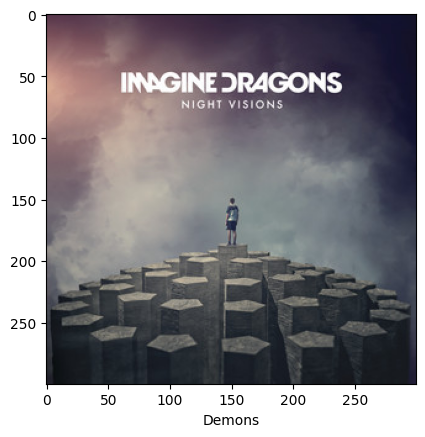

In [157]:
nome_musica = 'Imagine Dragons - Demons'
id = projection_kmeans.filter(projection_kmeans.artists_song == nome_musica).select('id').collect()[0][0]
track = sp.track(id)
url_imagem = track["album"]["images"][1]["url"]
name = track["name"]

image = io.imread(url_imagem)
plt.imshow(image)
plt.xlabel(name, fontsize = 10)
plt.show()


In [158]:
def visualize_songs(name, url):
  plt.figure(figsize=(15, 10))
  columns = 5
  for i, u in enumerate (url):
    ax = plt.subplot(len(url) // columns + 1, columns, i + 1)
    image = io.imread(u)
    plt.imshow(image)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.xticks(color = 'w', fontsize = 0.1)
    plt.yticks(color = 'w', fontsize = 0.1)
    plt.xlabel(name[i], fontsize = 10)
    plt.tight_layout(h_pad=0.7, w_pad=0)
    plt.subplots_adjust(wspace=None, hspace=None)
    plt.grid(visible=None)
  plt.show()

plt.subplot
O subplotdo Matplotlib é usado para que as imagens consigam ficar uma ao lado da outra, ou seja, para que as 10 capas de álbuns fiquem lado a lado. Os parâmetros são utilizados para criar o número de colunas exibidas.

plt.imshow
O imshow possibilita a observação dos dados como imagem, no caso a lista de urls em formato de imagem total. O parâmetro em questão vem do imread da biblioteca Scikit Image, mas, para saber quais outros parâmetros o imshow aceita, é necessário acessar a documentação do matplotlib.pyplot.imshow.

ax.get_yaxis().set_visible(False)
Quando usamos get_yaxis() estamos definindo que o eixo y é o foco da aplicação seguinte e dentro dele podem ser passados parâmetros, que não é o caso nesse momento.

A parte seguinte consiste em aplicarmos o set_visible() no eixo y, que aceita True e False como parâmetro. O True é o padrão, então a possibilidade, nesse caso, é utilizar o False para que o eixo y não apareça visualmente na resposta final.

plt.xticks e plt.yticks
O uso de plt.xticks e plt.yticks nos ajuda a obter e definir os locais e rótulos dos ticks de cada eixo, seja ele no eixo x ou y. Basicamente, os ticks podem ser personalizados e para a atual visualização, os parâmetros passados são a cor branca e o tamanho reduzido dos textos que existiam para que eles não aparecessem visualmente na imagem final.

plt.xlabel
Como os outros comandos de eixo, o plt.xlabel faz com que consigamos fazer modificações dentro do eixo x. Nesse caso, ele recebe um texto para ser colocado, o nome de cada música, e também é possível definir qual o tamanho da fonte que será utilizada.

plt.tight_layout
Esse módulo faz com que todos os outros se ajustem perfeitamente na figura, ou seja, qualquer módulo feito antes ou depois dele será ajustado, seja ele rótulo de eixo, marcação ou títulos de eixo.

plt.subplots_adjust
Esse método ajusta os parâmetros de layout da imagem e que podem ser estudados através da documentação em matplotlib.pyplot.subplots_adjust. No código passado em aula, o parâmetro wspace faz com que a largura de preenchimento das subparcelas seja ajustada, já o hspace é para a altura.

plt.tick_params
Esse módulo tem uma função semelhante ao que foi feito anteriormente com o ax.get_yaxis().set_visible(False). Porém, como estamos utilizando um método para adicionar o título no eixo x, não podemos removê-lo totalmente como o eixo y. Logo, utilizando o método plt.tick_params, é possível remover apenas os marcadores. P

plt.grid
Esse método é usado para retirar a grade da imagem gerada automaticamente nos plots do Matplotlib. O parâmetro utilizado é o visible=None

In [159]:
playlist_id = recomendadas.select('id').collect()

name = []
url = []

for id in playlist_id:
  track = sp.track(id[0])
  url.append(track["album"]["images"][1]["url"])
  name.append(track["name"])


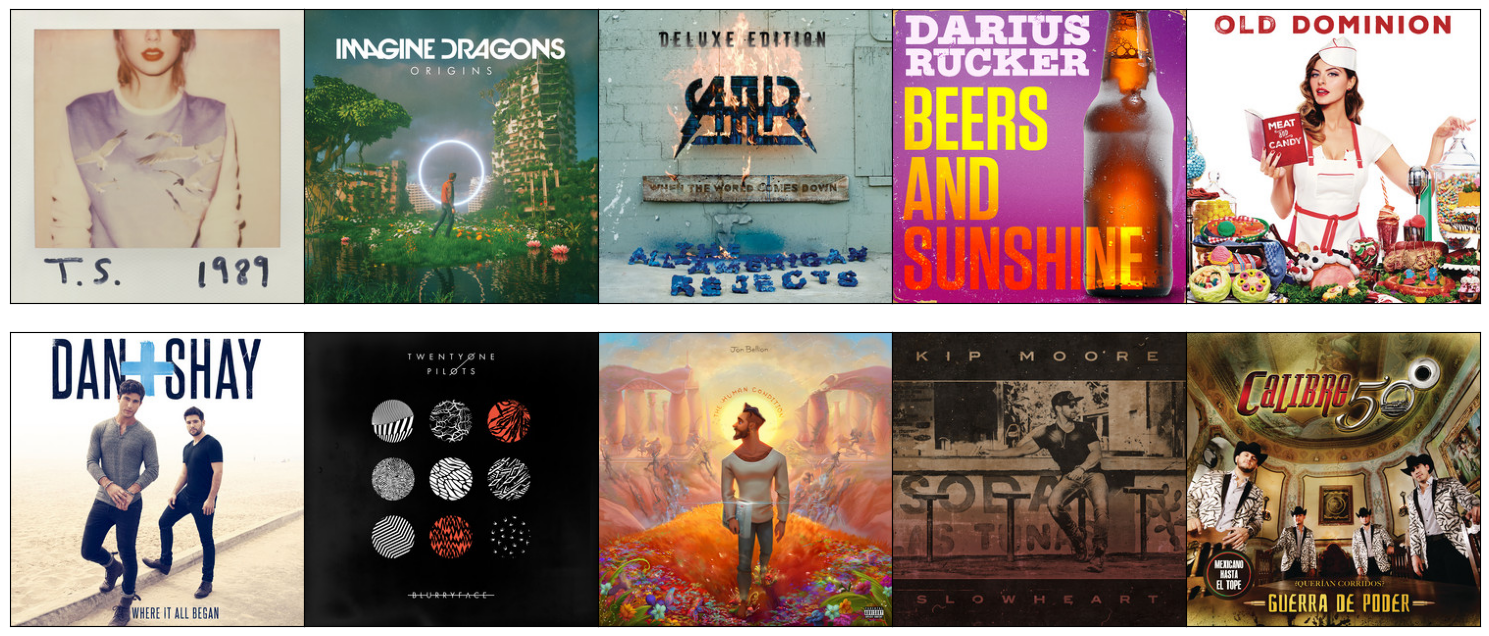

In [160]:
visualize_songs(name, url)

#Finalizando o Recomendador

In [163]:
def recomendador(nome_musica):
  # Calcula músicas recomendadas
  cluster = projection_kmeans.filter(projection_kmeans.artists_song == nome_musica).select('cluster_pca').collect()[0][0] # Primeiro identificamos o cluster
  musicas_recomendadas = projection_kmeans.filter(projection_kmeans.cluster_pca == cluster).select('artists_song', 'id', 'pca_features') # Então as músicas dentro desse cluster
  componentes_musica = musicas_recomendadas.filter(musicas_recomendadas.artists_song == nome_musica).select('pca_features').collect()[0][0] # Pegamos as coordenadas da música de referência

  def calcular_distancia(value):
    return euclidean(componentes_musica, value)

  udf_calcular_distancia = f.udf(calcular_distancia, FloatType())
  musicas_recomendadas_dist = musicas_recomendadas.withColumn('distancia', udf_calcular_distancia(musicas_recomendadas.pca_features))
  recomendadas = spark.createDataFrame(musicas_recomendadas_dist.sort('distancia').take(10)).select(['artists_song', 'id', 'distancia'])

  recomendadas.select('artists_song').show(truncate = False)

  #Pegar informações da API do Spotify

  playlist_id = recomendadas.select('id').collect() # Pegando o ID

  playlist_id_list = [] # Criando uma lista vazia
  name = []
  url = []

  for id in playlist_id:
    track = sp.track(id[0])
    url.append(track["album"]["images"][1]["url"])
    name.append(track["name"])

# Plotando as capas dos albuns

  plt.figure(figsize=(15, 10))
  columns = 5
  for i, u in enumerate (url):
    ax = plt.subplot(len(url) // columns + 1, columns, i + 1)
    image = io.imread(u)
    plt.imshow(image)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.xticks(color = 'w', fontsize = 0.1)
    plt.yticks(color = 'w', fontsize = 0.1)
    plt.xlabel(name[i], fontsize = 10)
    plt.tight_layout(h_pad=0.7, w_pad=0)
    plt.subplots_adjust(wspace=None, hspace=None)
    plt.grid(visible=None)
  plt.show()

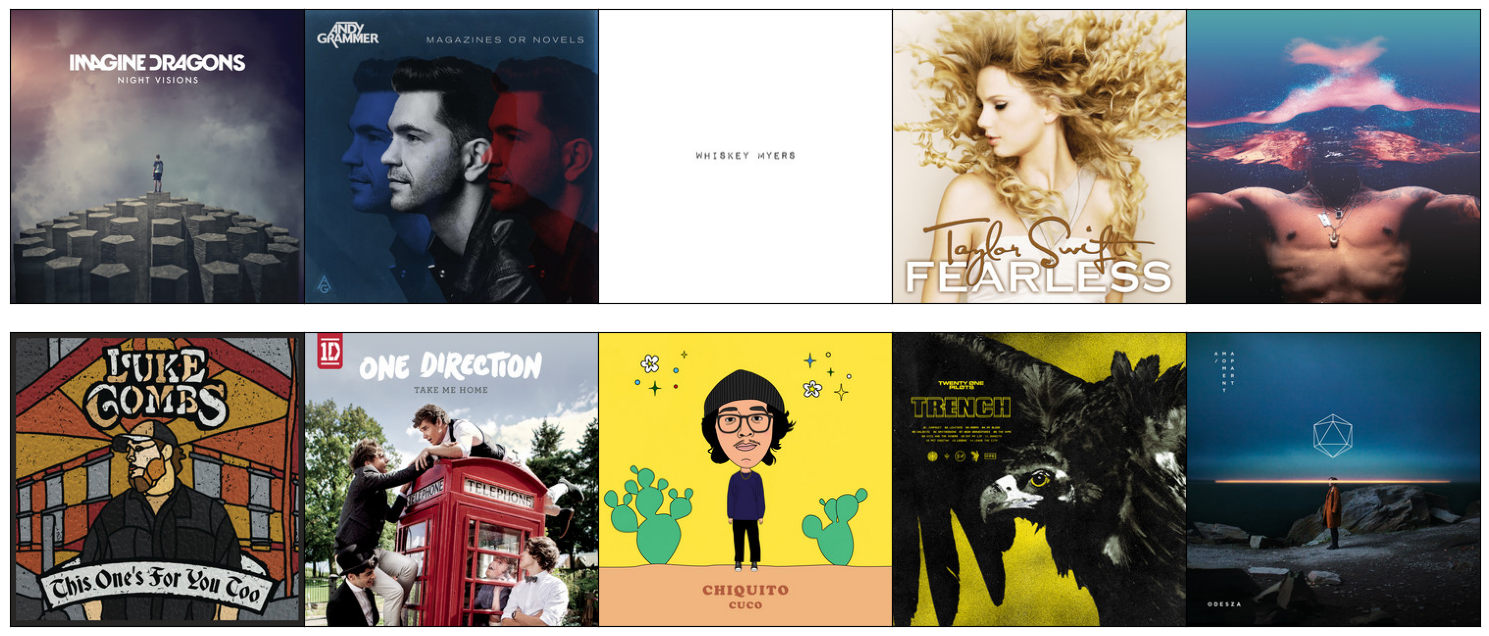

In [165]:
recomendador('Imagine Dragons - Demons')